# Detailed Chemistry Modeling in PrOMMiS: Tutorial for Chemical Precipitation
*A step-by-step guide for integrating Reaktoro and PrOMMiS models to predict precipitation performance*


---

## 1. Introduction

Chemical precipitation is a core mechanism in water treatment, hydrometallurgy, brine treatment, and critical mineral recovery. It describes the process in which dissolved ions combine to form a solid mineral phase once their activities exceed the solubility limit of that mineral.

Learning objectives:

- Modeling precipitation of various minerals 
- Adding reagents to control pH and alkalinity
- Setting up and solving a PrOMMiS flowsheet model with integrated Reaktoro chemistry databases and calculations




---

## 2. What Is Chemical Precipitation?

Chemical precipitation occurs when the **ionic activity product ($\text{IAP}$)** of certain ions exceeds a mineral’s **solubility product ($K_\text{sp}$)**:

$$
\text{IAP} = \prod_i a_i^{\nu_i},\qquad
\text{If IAP} > K_\text{sp},\ \text{mineral formation occurs.}
$$

Typical mineral categories for critical mineral and brine systems include:

- **Carbonates** (e.g., calcite, dolomite, siderite)  
- **Sulfates** (e.g., gypsum, barite)  
- **Hydroxides** (e.g., Mg(OH)₂, Fe(OH)₃)  
- **Mixed solid solutions** (e.g., transition-metal hydroxides or carbonates)

Reaktoro allows defining any number of aqueous species and solids from selected thermodynamic databases (e.g., PHREEQC, SUPCRT, and EQ3/6). Integrating these features into the PrOMMiS hub would enhance its existing predictive modeling for precipitation by incorporating detailed water chemistry.


---

## 3. Precipitation Softening Case Study

<p align="center">
<img src="precipitation_pfd.png" alt="Chemical Precipitation PFD" width="60%">
</p>

### 3.1 Lime-Soda Softening Chemistry

>**Goal:** precipitate calcium carbonate (calcite, $\text{CaCO}_3$) to reduce water hardness.

**Reagents:**


| Reagent | Purpose | Dose (mol/L) |
| :--- |:---:|:---:|
| Lime, $\text{CaO}$ | **Raise pH** to shift carbonate equilibrium toward ($\text{CO}_3^{2-}$) reducing solubility of calcite | 1e-5 |
| Soda Ash, $\text{Na}_2\text{CO}_3$ | **Provides carbonate ($\text{CO}_3^{2-}$) ions** for calcite precipitation | 1e-5 |

**Key reactions:**
|Reaction|Description|
|:---|:---:|
|$$\text{CaO} + \text{H}_2\text{O} \rightarrow \text{Ca}^{2+} + 2\text{OH}^-$$|Lime dissolves, releasing calcium and hydroxide ions, which raises pH.|
|$$\text{Na}_2\text{CO}_3 \rightarrow 2\text{Na}^+ + \text{CO}_3^{2-}$$|Soda ash dissociates, providing carbonate ions necessary for precipitation.|
|$$\text{Ca}^{2+} + \text{CO}_3^{2-} \rightarrow \text{CaCO}_3(s)$$|Calcium and carbonate ions combine to form solid calcite, reducing hardness.|

**The tradeoff:** Lime adds calcium but raises pH. Soda ash provides carbonate but costs more. What's the optimal balance in lime and soda ash dosing?

### 3.2 Feed Water Composition

| Ion | Concentration ($\text{mg/L}$) |
| :--- | :---: |
| $\text{Na}^+$ | 10556 |
| $\text{K}^+$ | 380 |
| $\text{Ca}^{2+}$ | 400 |
| $\text{Mg}^{2+}$ | 1272 |
| $\text{Cl}^-$ | 18980 |
| $\text{SO}_4^{2-}$ | 2649 |
| $\text{HCO}_3^-$ | 140 |


---

## 4. Precipitation Model with Detailed Chemistry

The development of the precipitation model is outlined here using a modular approach. This involves three steps:

1.  **Develop the Process Flowsheet Model:** Define the unit operations using **PrOMMiS** components.
2.  **Develop the Detailed Chemistry Model:** Use **Reaktoro-PSE** to accurately calculate chemical equilibrium, speciation, and mineral precipitation (using the Pitzer database) for the high-salinity feed stream.
3.  **Integrate:** Transfer the calculated chemistry parameters from Reaktoro into the PrOMMiS property model to achieve high-fidelity process simulation.

### 4.1 Import Modules from the Library
Import the core packages from [Pyomo](https://pyomo.readthedocs.io/en/stable/index.html), [IDAES](https://idaes-pse.readthedocs.io/en/stable/), and [Reaktoro PSE](https://github.com/watertap-org/reaktoro-pse)

In [1]:
## Import core components
from pyomo.environ import (
    Var,
    Param,
    Constraint,
    Expression,
    Objective,
    ConcreteModel,
    Block,
    value,
    assert_optimal_termination,
    units as pyunits,
)
from pyomo.util.calc_var_value import calculate_variable_from_constraint

# Ideas core components
from idaes.core import FlowsheetBlock
from idaes.core.util.scaling import set_scaling_factor, constraint_scaling_transform
from idaes.core.util.model_statistics import degrees_of_freedom
from idaes.core.initialization import BlockTriangularizationInitializer
from idaes.core.solvers import get_solver
from customized_liquid_properties import AqueousParameter
from customized_solids_properties import PrecipitateParameters
from prommis.precipitate.precipitator import Precipitator
import pyomo.environ as pyo

# Import reaktoro-pse and reaktoro
from reaktoro_pse.reaktoro_block import ReaktoroBlock
import reaktoro
from reaktoro_pse.core.util_classes.cyipopt_solver import get_cyipopt_watertap_solver

### 4.2 PrOMMiS Precipitator Model
The PrOMMiS [precipitator model](https://prommis.readthedocs.io/en/latest/_autosummary/prommis.precipitate.precipitator.html#module-prommis.precipitate.precipitator) is an equilibrium reactor that uses the “split” variable (`m.fs.properties_aq.split[comp]`) to define fixed partition coefficients. This specific variable dictates the recovery rate of components between the precipitate and aqueous phases, serving either as a fixed parameter or a variable determined by model-driven or surrogate-based equations.

This code illustrates the steps to set up the PrOMMiS precipitator model, including defining the flowsheet, adding the property packages for the aqueous and solid phases, adding the precipitator unit, specifying the feed conditions, and initializing the model.

In [2]:
m = ConcreteModel()
m.fs = FlowsheetBlock(dynamic=False)
# Property packages for aqueous and solid phases
m.fs.properties_aq = AqueousParameter()
m.fs.properties_solid = PrecipitateParameters()

# Precipitator unit model
m.fs.unit = Precipitator(
    property_package_aqueous=m.fs.properties_aq,
    property_package_precipitate=m.fs.properties_solid,
    make_volume_balance_constraint=False,
)

# Set inlet conditions for the aqueous stream
m.fs.unit.aqueous_inlet.flow_vol[0].fix(10000)  # mg/L
m.fs.unit.aqueous_inlet.conc_mass_comp[0, "Na"].fix(10556)
m.fs.unit.aqueous_inlet.conc_mass_comp[0, "K"].fix(380)
m.fs.unit.aqueous_inlet.conc_mass_comp[0, "Ca"].fix(400)
m.fs.unit.aqueous_inlet.conc_mass_comp[0, "Mg"].fix(1272)
m.fs.unit.aqueous_inlet.conc_mass_comp[0, "Cl"].fix(18980)
m.fs.unit.aqueous_inlet.conc_mass_comp[0, "SO4"].fix(2649)
m.fs.unit.aqueous_inlet.conc_mass_comp[0, "HCO3"].fix(140)

# Set temperature for the precipitate state block
m.fs.unit.precipitate_state_block[0].temperature.fix(298.15)

assert degrees_of_freedom(m.fs.unit) == 0
initializer = BlockTriangularizationInitializer(constraint_tolerance=2e-5)
initializer.initialize(m.fs.unit)
solver = get_solver()
results = solver.solve(m.fs.unit, tee=True)
assert_optimal_termination(results)

component keys that are not exported as part of the NL file.  Skipping.
Ipopt 3.13.2: nlp_scaling_method=gradient-based
tol=1e-06
max_iter=200


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the 

### 4.3 Solve with Fixed Performance

This example starts with a fixed-performance assumption for the precipitator, where calcium removal is set by a predefined split parameter rather than calculated from detailed chemistry.
First, we report the baseline removal efficiency using the default calcium precipitation setting.
Next, we update the assumed calcium precipitation to 43.12% and solve again to compare how the removal efficiency changes under that performance assumption.

In [3]:
print("\n--- Original Removal Efficiency ---")
print(f"Calcium Removal: {value(m.fs.properties_aq.split['Ca']):.2f} %")
print(
    f"Bicarbonate/Alkalinity Removal: {value(m.fs.properties_aq.split['HCO3']):.2f} %"
)
print("-" * 25)
results = solver.solve(m.fs.unit, tee=False)
assert_optimal_termination(results)
print("\n--- Original Results ---")
print("Treated Stream:")
print(
    f"Calcium Concentration: {value(m.fs.unit.aqueous_outlet.conc_mass_comp[0, 'Ca']):.2f} mg/L"
)
print(
    f"Bicarbonate/Alkalinity Concentration: {value(m.fs.unit.aqueous_outlet.conc_mass_comp[0, 'HCO3']):.2f} mg/L"
)
print("-" * 25)

# Fix performance
m.fs.properties_aq.split["Ca"] = 43.12  # assuming a fixed performance of the unit model
results = solver.solve(m.fs.unit, tee=False)
assert_optimal_termination(results)

print("\n--- Updated Removal Efficiency ---")
print(f"Calcium Removal: {value(m.fs.properties_aq.split['Ca']):.2f} %")
print(
    f"Bicarbonate/Alkalinity Removal: {value(m.fs.properties_aq.split['HCO3']):.2f} %"
)
print("-" * 25)
print("\n--- Updated Results ---")
print("Treated Stream:")
print(
    f"Calcium Concentration: {value(m.fs.unit.aqueous_outlet.conc_mass_comp[0, 'Ca']):.2f} mg/L"
)
print(
    f"Bicarbonate/Alkalinity Concentration: {value(m.fs.unit.aqueous_outlet.conc_mass_comp[0, 'HCO3']):.2f} mg/L"
)
print("-" * 25)


--- Original Removal Efficiency ---
Calcium Removal: 10.00 %
Bicarbonate/Alkalinity Removal: 0.00 %
-------------------------
component keys that are not exported as part of the NL file.  Skipping.

--- Original Results ---
Treated Stream:
Calcium Concentration: 360.00 mg/L
Bicarbonate/Alkalinity Concentration: 140.00 mg/L
-------------------------
component keys that are not exported as part of the NL file.  Skipping.

--- Updated Removal Efficiency ---
Calcium Removal: 43.12 %
Bicarbonate/Alkalinity Removal: 0.00 %
-------------------------

--- Updated Results ---
Treated Stream:
Calcium Concentration: 227.52 mg/L
Bicarbonate/Alkalinity Concentration: 140.00 mg/L
-------------------------


### 4.4. Integrating Detailed Chemistry into PrOMMiS Unit Models
An alternative to using fixed performance or surrogate models, is to integrate the model with a detailed chemistry package that **predicts** the precipitation based on the addition of agents and their concentration. Reaktoro-pse is a wrapper for enabling use of [Reaktoro](https://reaktoro.org/index.html) as a Graybox model in PrOMMiS. It allows users to leverage Reaktoro's powerful chemical equilibrium calculations within the PrOMMiS framework.



#### Create a Precipitation Process Block for Reaktoro Integration

The first step is to create a precipitation process block (as part of the precipitator PrOMMiS model). In this block, we will create all the parameters, variables, and constraints required to interface with Reaktoro PSE package.

In [4]:
# create new block as part of the precipitator PrOMMiS model
m.fs.unit.precipitation = Block()
################## Additional Variables and Parameters ########################
ions = list(
    m.fs.properties_aq.component_list
)  # read component list from precipitator property package

# New Variables
m.fs.unit.precipitation.feed_pH = Var(initialize=7.9)  # inlet pH
m.fs.unit.precipitation.feed_pressure = Var(
    initialize=1e5, units=pyunits.Pa
)  # inlet pressure
m.fs.unit.precipitation.reagents_mol_flow = Var(
    ["CaO", "Na2CO3"],
    initialize=1e-7,
    bounds=(1e-10, None),
    units=pyunits.mol / pyunits.s,
)  # reagent mol flow
m.fs.unit.precipitation.reagent_dose = Var(
    ["CaO", "Na2CO3"], initialize=1e-7, units=pyunits.mg / pyunits.kg
)  # reagent dose
m.fs.unit.precipitation.effluent_species_mass_flows = Var(
    ions, initialize=1e-5, units=pyunits.kg / pyunits.s
)  # effluent flow
m.fs.unit.precipitation.precipitants = Var(
    ["Calcite"], initialize=1e-32, units=pyunits.mol
)  # precipitants
m.fs.unit.precipitation.effluent_pH = Var(
    initialize=7, bounds=(5, 12), units=pyunits.dimensionless
)  # effluent pH
m.fs.unit.precipitation.effluent_alkalinity = Var(
    initialize=100, units=pyunits.mg / pyunits.L, bounds=(0.1, None)
)  # effluent alkalinity

# New Parameters
# Molecular weights of reagents and precipitants, which are needed to convert between molar flow and mass flow for the calculation of removal efficiencies and effluent composition.
m.fs.unit.precipitation.reagents_mw = Param(
    ["CaO", "Na2CO3"], units=pyunits.kg / pyunits.mol
)
m.fs.unit.precipitation.precipitants_mw = Param(
    ["Calcite"], initialize=100.09 / 1000, units=pyunits.kg / pyunits.mol
)
m.fs.unit.precipitation.reagents_mw["CaO"] = 56.0774 / 1000
m.fs.unit.precipitation.reagents_mw["Na2CO3"] = 105.99 / 1000

#### Add performance metrics
- Removal efficiency of calcium
- Removal efficiency of bicarbonate
- Effluent species mass flow rates

In [5]:
################## Additional Constraints / Expressions ######################

# expression that defines the mass flow of calcium in the inlet stream to the precipitation block, which is needed to calculate the removal efficiency of calcium
stoichiometric_coefficient_ca = 0.7183  # stoichiometric coefficient for calcium in the precipitation reaction (1 mol of CaO produces 0.7183 mol of Ca in the precipitate)
m.fs.unit.precipitation.mass_in_ca = pyo.Expression(
    expr=m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp["Ca"]
    + m.fs.unit.precipitation.reagents_mol_flow["CaO"]
    * m.fs.unit.precipitation.reagents_mw["CaO"]
    * stoichiometric_coefficient_ca
)

# constraint that defines the removal efficiency of calcium
m.fs.ca_removal = pyo.Constraint(
    expr=m.fs.properties_aq.split["Ca"]
    == 100
    * (
        1
        - m.fs.unit.precipitation.effluent_species_mass_flows["Ca"]
        / m.fs.unit.precipitation.mass_in_ca
    )
)

# constraint that defines the removal efficiency of bicarbonate/alkalinity
m.fs.hco3_removal = pyo.Constraint(
    expr=m.fs.properties_aq.split["HCO3"]
    == 100
    * (
        m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp["HCO3"]
        - m.fs.unit.precipitation.effluent_species_mass_flows["HCO3"]
    )
    / m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp["HCO3"]
)


# constraint that defines the effluent mass flow of each species based on the inlet aqueous composition, the reagent dose, and the amount of formed precipitate. For Ca and HCO3, the mass flow is also affected by the amount of formed calcite, while for Na, the mass flow is affected by the re-agent dose of Na2CO3. For other species, the effluent mass flow is equal to the inlet mass flow since they are not involved in the precipitation reaction.
@m.fs.unit.precipitation.Constraint(ions)
def eq_effluent_species_mass_flows(fs, ion):
    if "Ca" == ion:
        return m.fs.unit.precipitation.effluent_species_mass_flows["Ca"] == (
            m.fs.unit.precipitation.reagents_mol_flow["CaO"]
            * m.fs.properties_aq.mw["Ca"]
            + m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp["Ca"]
            - m.fs.unit.precipitation.precipitants["Calcite"]
            * m.fs.properties_aq.mw["Ca"]
            / pyo.units.s
        )
    elif "Na" == ion:
        return m.fs.unit.precipitation.effluent_species_mass_flows["Na"] == (
            2
            * m.fs.unit.precipitation.reagents_mol_flow["Na2CO3"]
            * m.fs.properties_aq.mw["Na"]
            + m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp["Na"]
        )
    elif "HCO3" == ion:
        return m.fs.unit.precipitation.effluent_species_mass_flows["HCO3"] == (
            m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp["HCO3"]
            + m.fs.unit.precipitation.reagents_mol_flow["Na2CO3"]
            * m.fs.properties_aq.mw["HCO3"]
            - m.fs.unit.precipitation.precipitants["Calcite"]
            * m.fs.properties_aq.mw["HCO3"]
            / pyo.units.s
        )
    else:
        return (
            m.fs.unit.precipitation.effluent_species_mass_flows[ion]
            == m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp[ion]
        )

#### Add Reaktoro Chemistry Block

Specify the following to build the Reaktoro Graybox model (`ReaktoroBlock`):

- Input ion composition (apparent or exact species)
- System temperature, pressure, pH, and charge neutrality
- Mineral phases to consider for precipitation
- Reagent dosages (e.g., lime and soda ash)
- Reaktoro databases and activity models
- Outputs supported by Reaktoro and custom outputs built using Reaktoro database information and outputs

>The `ReaktoroBlock` automatically creates a Reaktoro Graybox as an IDAES StateBlock.

In [6]:
################## Reaktoro-pse Interface Inputs/Outputs ###################
# mapping of reaktoro block outputs to model variables - this is needed to link the chemistry model to the performance of the unit model
# note the outputs from Reaktoro-PSE will be in moles, so we need to convert them to mass flow for the unit model.
m.fs.unit.precipitation.reaktoro_outputs = {
    (
        "speciesAmount",
        "Calcite",
    ): m.fs.unit.precipitation.precipitants["Calcite"],
    ("alkalinityAsCaCO3", None): m.fs.unit.precipitation.effluent_alkalinity,
    ("pH", None): m.fs.unit.precipitation.effluent_pH,
}
# definition of the reaktoro block
# the reaktoro block is defined as a constraint block that takes the aqueous composition, system state, and mineral phase as inputs and outputs the amount of formed precipitate, effluent alkalinity, and effluent pH
m.fs.unit.precipitation.eq_precipitation = ReaktoroBlock(
    aqueous_phase={
        "composition": m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp,
        "convert_to_rkt_species": True,  # Mapping of aqueous species to reaktoro species names
        "activity_model": reaktoro.ActivityModelPitzer(),
        "fixed_solvent_specie": "H2O",
    },
    system_state={
        "temperature": m.fs.unit.precipitate_state_block[0].temperature,
        "pressure": m.fs.unit.precipitation.feed_pressure,
        "pH": m.fs.unit.precipitation.feed_pH,
    },
    mineral_phase={"phase_components": ["Calcite"]},
    chemistry_modifier={
        "CaO": m.fs.unit.precipitation.reagents_mol_flow["CaO"],
        "Na2CO3": m.fs.unit.precipitation.reagents_mol_flow["Na2CO3"],
    },
    outputs=m.fs.unit.precipitation.reaktoro_outputs,
    database_file="pitzer.dat",
    build_speciation_block=True,
)


## constraint that defines the reagent dose based on the reagent mol flow and the aqueous flow composition.
@m.fs.unit.precipitation.Constraint(["CaO", "Na2CO3"])
def eq_dose(fs, reagent):
    return m.fs.unit.precipitation.reagent_dose[reagent] == pyunits.convert(
        m.fs.unit.precipitation.reagents_mol_flow[reagent]
        * m.fs.unit.precipitation.reagents_mw[reagent]
        / m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp["H2O"],
        to_units=pyunits.mg / pyunits.kg,
    )

2026-05-11 20:24:36 [INFO] idaes.reaktoro_pse.core.reaktoro_inputs: Exact speciation is not provided! Fixing aqueous solvent and, excluding O
2026-05-11 20:24:36 [INFO] idaes.reaktoro_pse.core.reaktoro_inputs: Exact speciation is not provided! Fixing aqueous solvent and, excluding H
2026-05-11 20:24:36 [INFO] idaes.reaktoro_pse.core.reaktoro_solver: rktSolver inputs: ['[Cl]', '[C]', '[Na]', '[Mg]', '[S]', '[K]', '[Ca]', '[H2O]', '[O]', '[H]', '[H+]']
2026-05-11 20:24:36 [INFO] idaes.reaktoro_pse.core.reaktoro_solver: rktSolver constraints: ['charge', 'C_constraint', 'Na_constraint', 'Mg_constraint', 'S_constraint', 'K_constraint', 'Ca_constraint', 'H2O_constraint', 'O_dummy_constraint', 'H_dummy_constraint', 'pH']
2026-05-11 20:24:36 [INFO] idaes.reaktoro_pse.core.reaktoro_solver: rktSolver inputs: ['[H+]', '[H]', '[C]', '[O]', '[Na]', '[Mg]', '[S]', '[Cl]', '[K]', '[Ca]']
2026-05-11 20:24:36 [INFO] idaes.reaktoro_pse.core.reaktoro_solver: rktSolver constraints: ['charge', 'H_constrain

***WARNING***
The chosen thermodynamic model for the aqueous phase produced volume 0 L, which is not physical. As an approximation, alkalinity will be computed using density of pure water provided by Wagner & Pruss (2002) model as the density of the solution. Was the Extended UNIQUAC the chosen model? It currently does not compute densities for lack of standard molar volumes of the species. Disable this warning message with Warnings.disable(345) in Python and Warnings::disable(345) in C++.


#### Solve with Reaktoro Chemistry integration

Fix inputs (pH, pressure, reagent dosages) and unfix the split fractions for calcium and bicarbonate (these are derived from the chemistry calculations).
After scaling and initialization, solve the model to predict precipitation performance based on detailed chemistry calculations from Reaktoro.

In [7]:
################## Fix Inputs and Model Scaling #############################
m.fs.unit.precipitation.feed_pH.fix(
    7.9
)  # fixing pH (value given in the problem statement)
m.fs.unit.precipitation.feed_pressure.fix(
    1e5
)  # fixing pressure (value given in the problem statement)
m.fs.unit.precipitation.reagents_mol_flow["CaO"].fix(
    0.01
)  # fixing reagent flow mol (value given in the problem statement)
m.fs.unit.precipitation.reagents_mol_flow["Na2CO3"].fix(
    0.01
)  # fixing reagent flow mol (value given in the problem statement)
m.fs.properties_aq.split[
    "Ca"
].unfix()  # unfixing variable - the model performance is now linked to the reaktoro chemistry model
m.fs.properties_aq.split[
    "HCO3"
].unfix()  # unfixing variable - the model performance is now linked to the reaktoro chemistry model

# Scaling
set_scaling_factor(m.fs.unit.precipitation.feed_pH, 1)
set_scaling_factor(m.fs.unit.precipitate_state_block[0].temperature, 1 / 273)
set_scaling_factor(m.fs.unit.precipitation.feed_pressure, 1e-5)

# Initialization
for comp, pyoobj in m.fs.unit.precipitation.eq_effluent_species_mass_flows.items():
    calculate_variable_from_constraint(
        m.fs.unit.precipitation.effluent_species_mass_flows[comp], pyoobj
    )
    set_scaling_factor(
        m.fs.unit.precipitation.effluent_species_mass_flows[comp],
        1 / m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp[comp].value,
    )
    constraint_scaling_transform(
        pyoobj, 1 / m.fs.unit.cv_aqueous.properties_in[0].flow_mass_comp[comp].value
    )

for reagent in m.fs.unit.precipitation.reagents_mol_flow.keys():
    set_scaling_factor(m.fs.unit.precipitation.reagents_mol_flow[reagent], 1e4)
    set_scaling_factor(m.fs.unit.precipitation.reagent_dose[reagent], 1)
    constraint_scaling_transform(m.fs.unit.precipitation.eq_dose[reagent], 1)

for reagent in m.fs.unit.precipitation.precipitants.keys():
    set_scaling_factor(m.fs.unit.precipitation.precipitants[reagent], 1e4)
set_scaling_factor(m.fs.unit.precipitation.effluent_pH, 1)
m.fs.unit.precipitation.eq_precipitation.initialize()

# recompute effluent composition using updated amount of formed calcite
for comp, pyoobj in m.fs.unit.precipitation.eq_effluent_species_mass_flows.items():
    calculate_variable_from_constraint(
        m.fs.unit.precipitation.effluent_species_mass_flows[comp], pyoobj
    )

print("Model Degrees of Freedom = " + str(degrees_of_freedom(m)))
solver = get_cyipopt_watertap_solver(max_iter=200, linear_solver="mumps", pivtol=1e-4)
result = solver.solve(m, tee=False)
assert_optimal_termination(result)  # check optimal condition

2026-05-11 21:08:49 [INFO] idaes.reaktoro_pse.reaktoro_block: ---initializing property block fs.unit.precipitation.eq_precipitation----
2026-05-11 21:08:49 [INFO] idaes.reaktoro_pse.core.reaktoro_state: Equilibrated successfully
2026-05-11 21:08:49 [INFO] idaes.reaktoro_pse.core.reaktoro_state: Equilibrated successfully
2026-05-11 21:08:49 [INFO] idaes.reaktoro_pse.core.reaktoro_block_builder: Initialized rkt block
Model Degrees of Freedom = 0


### 4.3. Results
Precipitation removed ~43% of influent calcium using 201.8 mg/kg lime and 381.5 mg/kg soda ash, raising pH from 7 to 11.

In [8]:
# print results from Reaktoro object
print("--- Reaktoro Object Results ---")
for key, obj in m.fs.unit.precipitation.reaktoro_outputs.items():
    print(key, value(obj))

# Print Precipitator Model Results
print("\n-----------------------")
print("--- Results Summary ---")
print("-----------------------")
print("\n--- Influent ---")
print(f"Flow: {value(m.fs.unit.aqueous_inlet.flow_vol[0]):.2f}  L/h")
print(f"Temperature: {value(m.fs.unit.precipitate_state_block[0].temperature):.2f} K")
print(f"Pressure: {value(m.fs.unit.precipitation.feed_pressure):.2f} Pa")
print(f"pH: {value(m.fs.unit.precipitation.feed_pH):.2f}")
print(
    f"Calcium concentration: {value(m.fs.unit.aqueous_inlet.conc_mass_comp[0, 'Ca']):.2f} mg/L"
)
print(
    f"Bicarbonate/Alkalinity concentration: {value(m.fs.unit.aqueous_inlet.conc_mass_comp[0, 'HCO3']):.2f} mg/L"
)
print("\n--- Treated Effluent ---")
print(f"pH: {value(m.fs.unit.precipitation.effluent_pH):.2f}")
print(
    f"Calcium concentration: {value(m.fs.unit.aqueous_outlet.conc_mass_comp[0, 'Ca']):.2f} mg/L"
)
print(
    f"Bicarbonate/Alkalinity Concentration: {value(m.fs.unit.aqueous_outlet.conc_mass_comp[0, 'HCO3']):.2f} mg/L"
)
print("-" * 25)
print("\n--- Precipitation Reagent Dosing ---")
print(
    f"Quicklime (CaO) Dose: {value(m.fs.unit.precipitation.reagent_dose['CaO']):.3f} mg/kg"
)
print(
    f"Soda Ash (Na2CO3) Dose: {value(m.fs.unit.precipitation.reagent_dose['Na2CO3']):.3f} mg/kg"
)
print("-" * 25)
print("\n--- Removal Efficiencies ---")
print(f"Calcium Removal: {value(m.fs.properties_aq.split['Ca']):.2f} %")
print(
    f"Bicarbonate/Alkalinity Removal: {value(m.fs.properties_aq.split['HCO3']):.2f} %"
)
print("-" * 25)

--- Reaktoro Object Results ---
('speciesAmount', 'Calcite') 0.01623646182274176
('alkalinityAsCaCO3', None) 0.2945122567812926
('pH', None) 11.160523533610906

-----------------------
--- Results Summary ---
-----------------------

--- Influent ---
Flow: 10000.00  L/h
Temperature: 298.15 K
Pressure: 100000.00 Pa
pH: 7.90
Calcium concentration: 400.00 mg/L
Bicarbonate/Alkalinity concentration: 140.00 mg/L

--- Treated Effluent ---
pH: 11.16
Calcium concentration: 227.53 mg/L
Bicarbonate/Alkalinity Concentration: 3.01 mg/L
-------------------------

--- Precipitation Reagent Dosing ---
Quicklime (CaO) Dose: 201.879 mg/kg
Soda Ash (Na2CO3) Dose: 381.564 mg/kg
-------------------------

--- Removal Efficiencies ---
Calcium Removal: 43.12 %
Bicarbonate/Alkalinity Removal: 97.85 %
-------------------------


### 4.3 Sensitivity Analysis
The sensitivity analysis captures the performance change when adjusting the molar flowrate of the lime and soda ash and its impact on the precipitation performance. Thus, we can observe the efficiency of the process to precipitate calcium as a function of the lime and soda ash dose. In addition, we can observe the pH change as a function of lime and soda ash dose, which confirms our initial statement. The results confirm that raising the pH above 7 reduces the solubility of calcite, and adding soda ash facilitates calcite formation. 

In [6]:
import numpy as np
import pyomo.environ as pyo

disturbance = np.linspace(0.01, 0.04, 5)  # process control disturbance - or change

# intermediate objects to store the results
pH = []
precipitants = []
alkal = []
ca_removal_l = []
hco3_removal_l = []
effluent_ph_l = []
soda_ash_dose_l = []
lime_dose_l = []

# solve a series of PrOMMiS optimization models to capture the disturbance effects on critical variables
for l in disturbance:
    # update PrOMMiS model variable values
    m.fs.unit.precipitation.reagents_mol_flow["CaO"].fix(l)
    m.fs.unit.precipitation.reagents_mol_flow["Na2CO3"].fix(l)
    result = solver.solve(m, tee=False)  # solve model
    assert_optimal_termination(result)  # check model is optimal
    # save results
    lime_dose_l.append(value(m.fs.unit.precipitation.reagent_dose["CaO"]))
    soda_ash_dose_l.append(value(m.fs.unit.precipitation.reagent_dose["Na2CO3"]))
    pH.append(m.fs.unit.precipitation.effluent_pH.value)
    precipitants.append(m.fs.unit.precipitation.precipitants["Calcite"].value)
    alkal.append(pyo.value(m.fs.unit.precipitation.effluent_alkalinity))
    ca_removal_l.append(value(m.fs.properties_aq.split["Ca"]))
    hco3_removal_l.append(value(m.fs.properties_aq.split["HCO3"]))

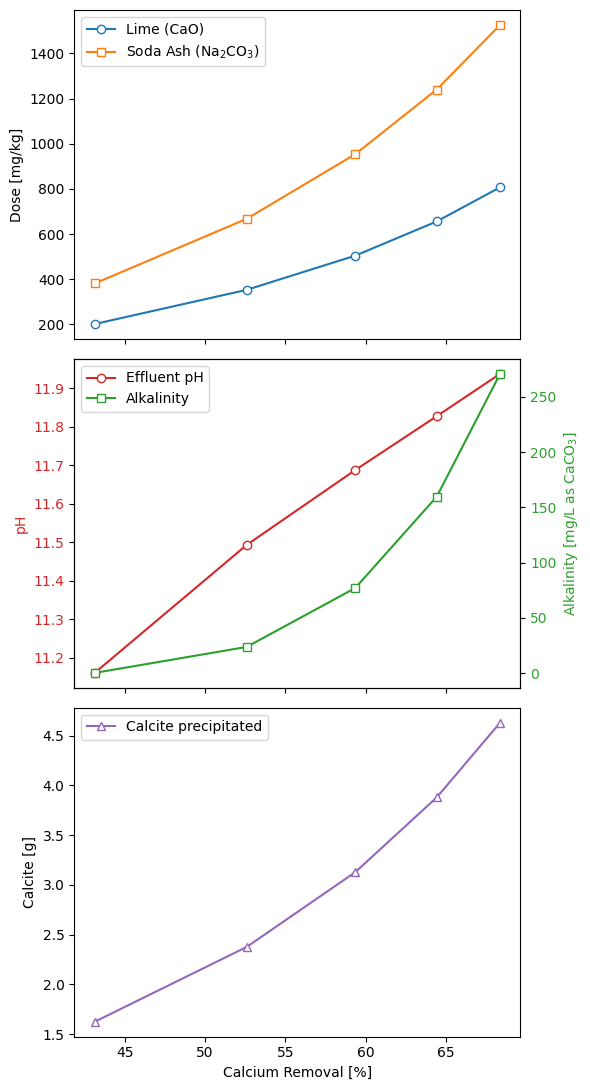

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcite in grams
mw_calcite_g_per_mol = value(
    pyunits.convert(
        m.fs.unit.precipitation.precipitants_mw["Calcite"],
        to_units=pyunits.g / pyunits.mol,
    )
)

calcite_g = [n_mol * mw_calcite_g_per_mol for n_mol in precipitants]

# optional: sort by calcium removal so lines are monotonic in x
idx = np.argsort(ca_removal_l)
x = np.array(ca_removal_l)[idx]
lime = np.array(lime_dose_l)[idx]
soda = np.array(soda_ash_dose_l)[idx]
ph = np.array(pH)[idx]
alk = np.array(alkal)[idx]
calcite = np.array(calcite_g)[idx]  # Calcite amount (g)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 11), sharex=True)

# Subplot 1: reagent doses
ax1.plot(x, lime, marker="o", markerfacecolor="white", label="Lime (CaO)")
ax1.plot(x, soda, marker="s", markerfacecolor="white", label="Soda Ash (Na$_2$CO$_3$)")
ax1.set_ylabel("Dose [mg/kg]")
ax1.legend(loc="best")

# Subplot 2: pH + alkalinity (double y-axis)
ax2_r = ax2.twinx()
(l1,) = ax2.plot(
    x, ph, color="tab:red", marker="o", markerfacecolor="white", label="Effluent pH"
)
(l2,) = ax2_r.plot(
    x, alk, color="tab:green", marker="s", markerfacecolor="white", label="Alkalinity"
)

ax2.set_ylabel("pH", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2_r.set_ylabel("Alkalinity [mg/L as CaCO$_3$]", color="tab:green")
ax2_r.tick_params(axis="y", labelcolor="tab:green")
ax2.legend([l1, l2], [l1.get_label(), l2.get_label()], loc="best")

# Subplot 3: Calcite precipitation
ax3.plot(
    x,
    calcite,
    color="tab:purple",
    marker="^",
    markerfacecolor="white",
    label="Calcite precipitated",
)
ax3.set_xlabel("Calcium Removal [%]")
ax3.set_ylabel("Calcite [g]")
ax3.legend(loc="best")

plt.tight_layout()
plt.show()